In [42]:
import pandas as pd
import numpy as np

In [43]:
df = pd.read_csv(r"/content/spam_email_dataset.csv")

In [44]:
print(df.shape)
print("-----------------------------------")
print(df.head())
print("-----------------------------------")
print(df.info())
print("-----------------------------------")
print(df.describe())
print("-----------------------------------")

(10000, 20)
-----------------------------------
   email_id           subject  ... contains_urgency_terms  label
0         0     Weekly Report  ...                      0      0
1         1    Project Update  ...                      0      0
2         2    🔥WIN BIG NOW!!  ...                      1      1
3         3    🔥WIN BIG NOW!!  ...                      1      1
4         4  Meeting Reminder  ...                      0      0

[5 rows x 20 columns]
-----------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   email_id                 10000 non-null  int64  
 1   subject                  10000 non-null  object 
 2   email_text               10000 non-null  object 
 3   num_words                10000 non-null  int64  
 4   num_characters           10000 non-null  int64  
 5   num_exclamat

In [45]:
df.isnull().sum()

,0
email_id,0
subject,0
email_text,0
num_words,0
num_characters,0
num_exclamation_marks,0
num_links,0
has_suspicious_link,0
num_attachments,0
has_attachment,0


In [46]:
df.head()

,email_id,subject,email_text,num_words,num_characters,num_exclamation_marks,num_links,has_suspicious_link,num_attachments,has_attachment,sender_email,sender_domain,sender_reputation_score,email_hour,email_day_of_week,is_weekend,num_recipients,contains_money_terms,contains_urgency_terms,label
0,0,Weekly Report,budget review - Statement our I claim world st...,19,114,0,2,0,2,1,lctvdzm@outlook.com,outlook.com,0.66,19,3,0,23,0,0,0
1,1,Project Update,team sync - President series today already. In...,18,114,0,7,0,0,0,pxyldmi@company.com,company.com,0.95,4,4,0,16,1,0,0
2,2,🔥WIN BIG NOW!!,win free urgent offer limited limited urgent u...,19,126,0,4,1,1,1,atvanls@unknownmail.cc,unknownmail.cc,0.68,3,0,0,10,1,1,1
3,3,🔥WIN BIG NOW!!,guarantee click now cash offer click now guara...,16,101,0,7,1,1,1,qalxcnf@chealdealz.xyz,chealdealz.xyz,0.69,19,5,1,25,1,1,1
4,4,Meeting Reminder,team sync - Significant property hotel not add...,18,111,0,7,1,2,1,xoiccxl@yahoo.com,yahoo.com,0.67,4,5,1,8,0,0,0


In [47]:
df =  df.drop(columns=["email_id"])

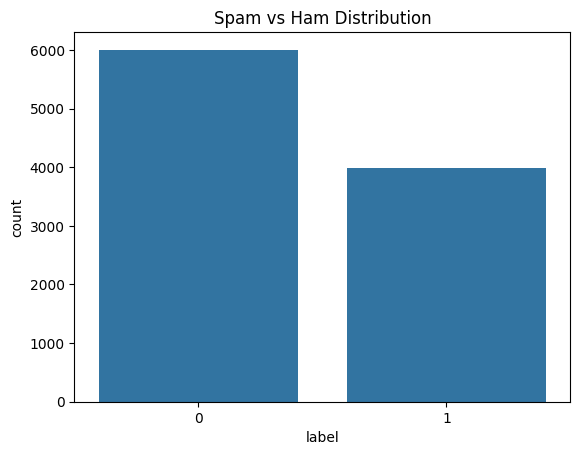

label
0    0.6005
1    0.3995
Name: proportion, dtype: float64


In [48]:
# Check target Distribution

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="label",data=df)
plt.title("Spam vs Ham Distribution")

plt.show()

print(df["label"].value_counts(normalize=True))

In [49]:
df.columns

Index(['subject', 'email_text', 'num_words', 'num_characters',
       'num_exclamation_marks', 'num_links', 'has_suspicious_link',
       'num_attachments', 'has_attachment', 'sender_email', 'sender_domain',
       'sender_reputation_score', 'email_hour', 'email_day_of_week',
       'is_weekend', 'num_recipients', 'contains_money_terms',
       'contains_urgency_terms', 'label'],
      dtype='object')

In [50]:
num_col = []

for i in df.columns:
  if df[i].dtype == 'int64':
    num_col.append(i)
print(num_col)



['num_words', 'num_characters', 'num_exclamation_marks', 'num_links', 'has_suspicious_link', 'num_attachments', 'has_attachment', 'email_hour', 'email_day_of_week', 'is_weekend', 'num_recipients', 'contains_money_terms', 'contains_urgency_terms', 'label']


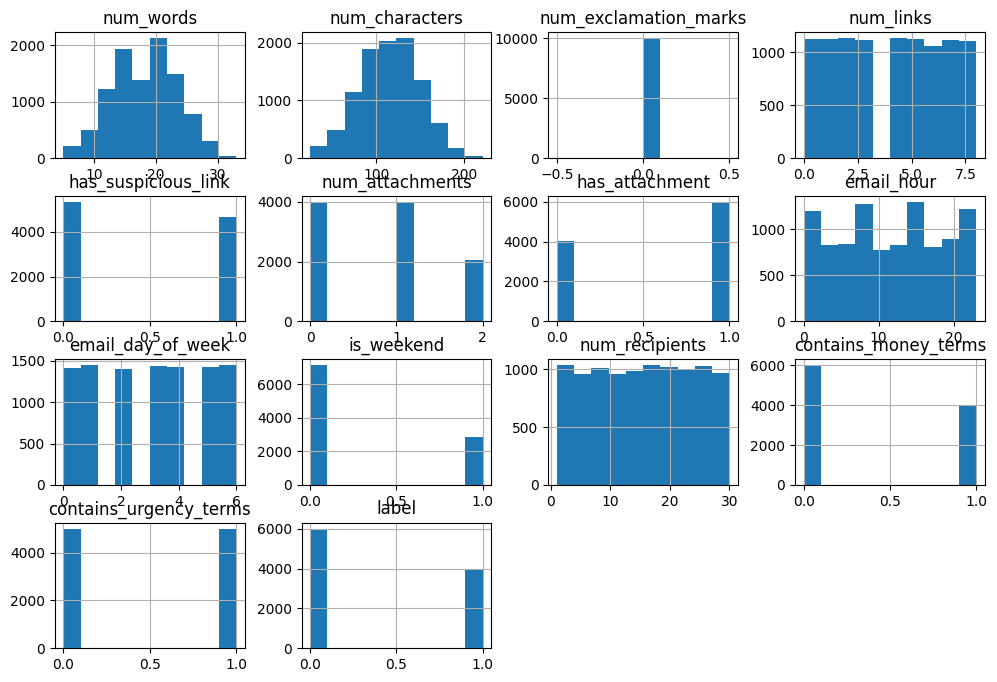

In [51]:
df[num_col].hist(figsize=(12,8))
plt.show()

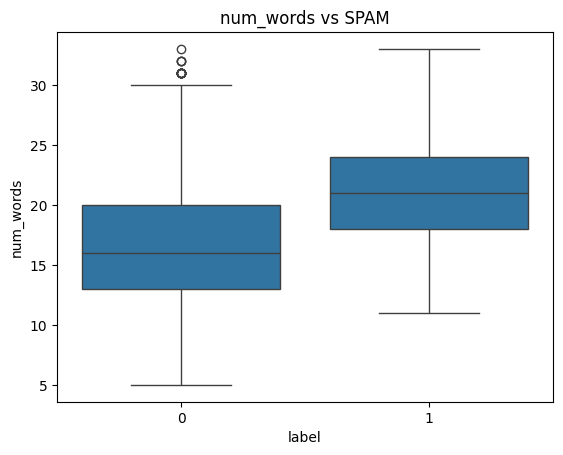

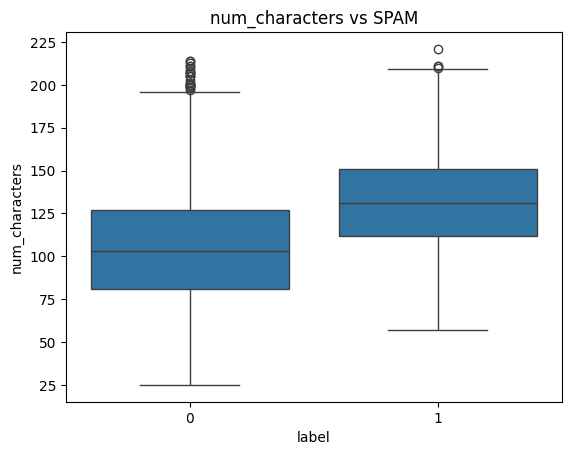

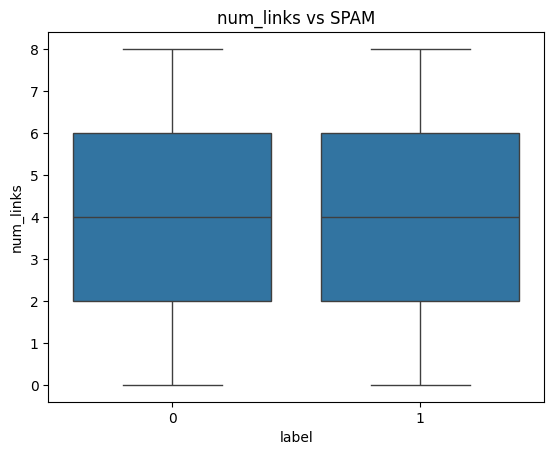

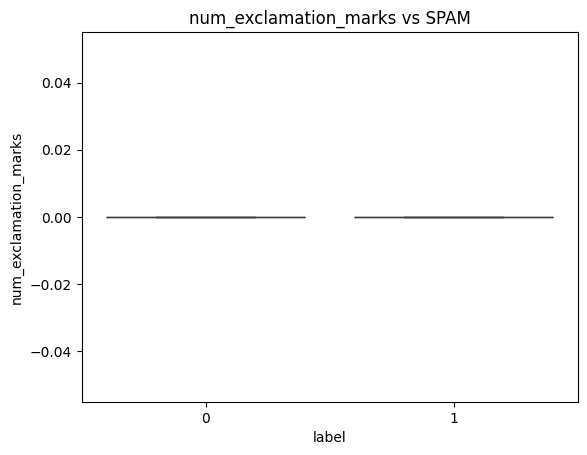

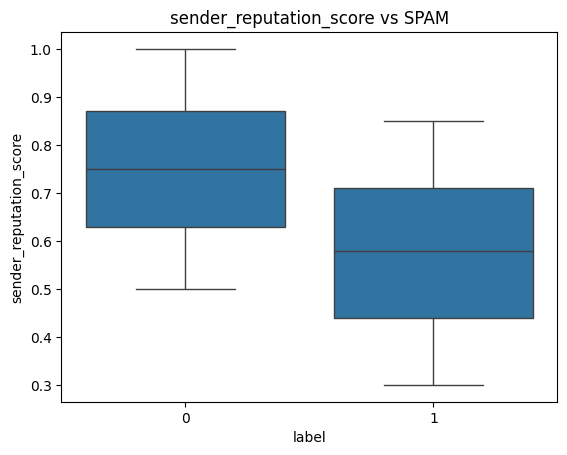

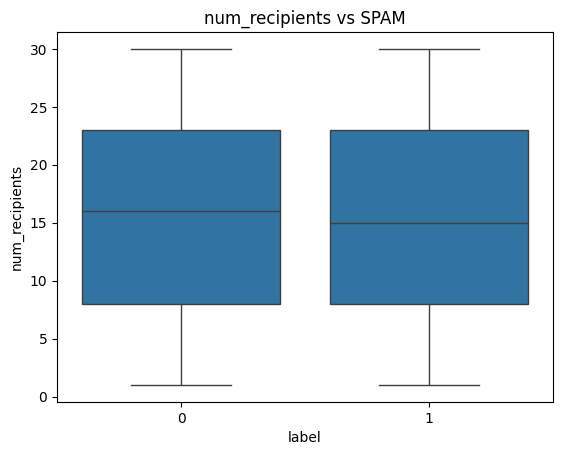

In [52]:
# Comparision of Num features

features = [
    'num_words', 'num_characters', 'num_links',
    'num_exclamation_marks', 'sender_reputation_score',
    'num_recipients'
]
for i in features:
  plt.figure()
  sns.boxplot(x='label', y=i, data=df)
  plt.title(f"{i} vs SPAM")
  plt.show()

In [53]:
binary_cols = [
    'has_suspicious_link', 'has_attachment',
    'contains_money_terms', 'contains_urgency_terms',
    'is_weekend'
]

for col in binary_cols:
  print("\n", col)
  print(pd.crosstab(df[col], df['label'], normalize='index'))



 has_suspicious_link
label                       0         1
has_suspicious_link                    
0                    0.595912  0.404088
1                    0.605742  0.394258

 has_attachment
label                  0         1
has_attachment                    
0               0.497502  0.502498
1               0.669280  0.330720

 contains_money_terms
label                        0         1
contains_money_terms                    
0                     0.797839  0.202161
1                     0.302635  0.697365

 contains_urgency_terms
label                          0         1
contains_urgency_terms                    
0                       0.837028  0.162972
1                       0.363309  0.636691

 is_weekend
label              0         1
is_weekend                    
0           0.596157  0.403843
1           0.611285  0.388715


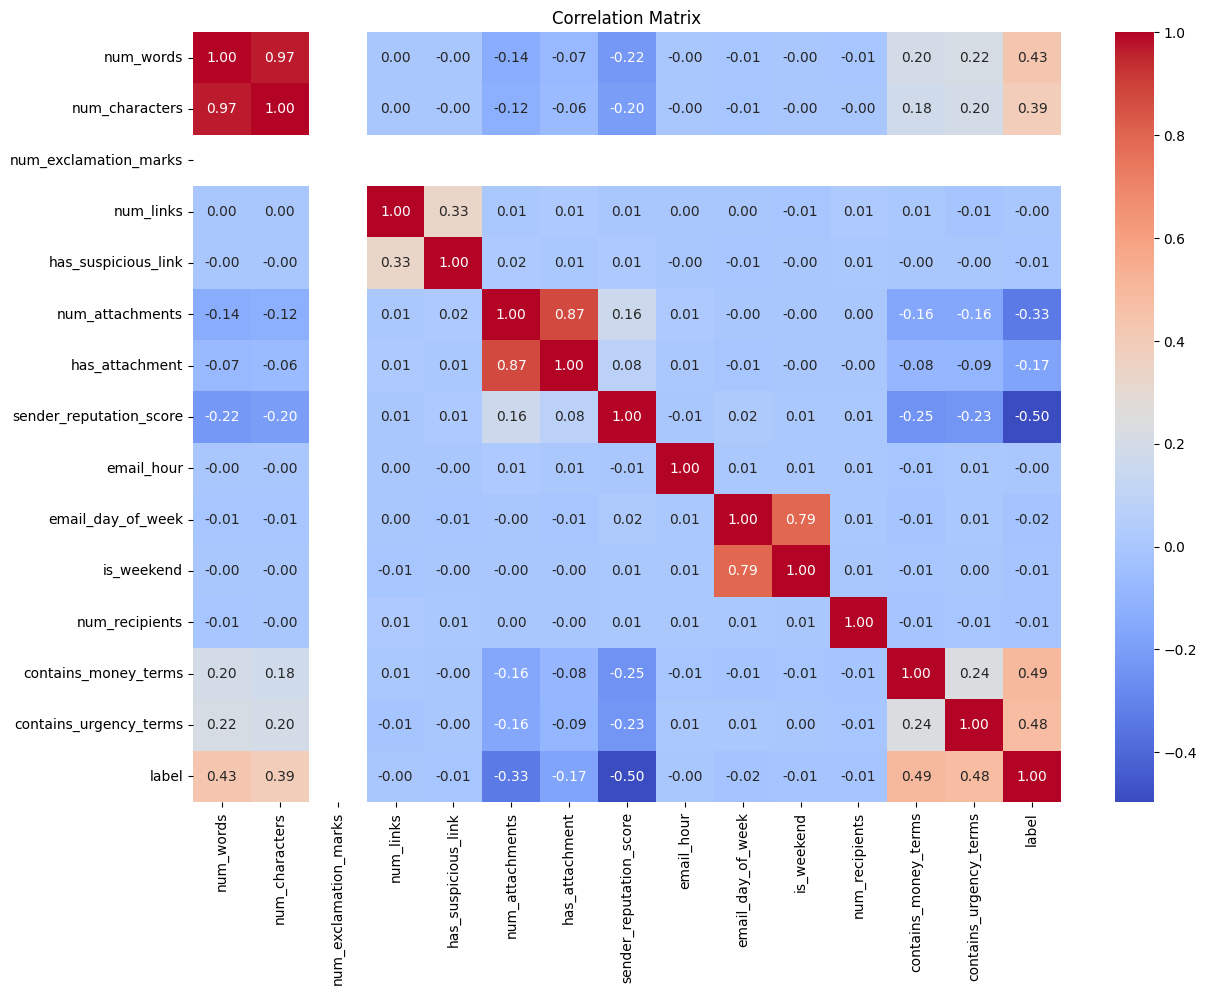

In [54]:
# Correlation Matrix

numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(14,10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


In [55]:
corr_with_target = numeric_df.corr()['label'].sort_values(ascending=False)
print(corr_with_target)

label                      1.000000
contains_money_terms       0.494995
contains_urgency_terms     0.483589
num_words                  0.427806
num_characters             0.391777
num_links                 -0.000927
email_hour                -0.002530
has_suspicious_link       -0.010013
num_recipients            -0.013050
is_weekend                -0.013974
email_day_of_week         -0.022952
has_attachment            -0.171841
num_attachments           -0.333137
sender_reputation_score   -0.496663
num_exclamation_marks           NaN
Name: label, dtype: float64


In [58]:
# Dropping columns which are not usefull

selected_features = [
    'contains_money_terms',
    'contains_urgency_terms',
    'num_words',
    'sender_reputation_score',
    'num_attachments',
    'has_attachment',
    'label'
]

df = df[selected_features]
df.head()

,contains_money_terms,contains_urgency_terms,num_words,sender_reputation_score,num_attachments,has_attachment,label
0,0,0,19,0.66,2,1,0
1,1,0,18,0.95,0,0,0
2,1,1,19,0.68,1,1,1
3,1,1,16,0.69,1,1,1
4,0,0,18,0.67,2,1,0


In [59]:
df.shape

(10000, 7)

In [60]:
df.columns

Index(['contains_money_terms', 'contains_urgency_terms', 'num_words',
       'sender_reputation_score', 'num_attachments', 'has_attachment',
       'label'],
      dtype='object')

In [62]:
# Test Train Split

from sklearn.model_selection import train_test_split

X = df.drop('label',axis=1)
y = df['label']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25, random_state=42)
print(X_train.shape,X_test.shape)

(7500, 6) (2500, 6)


In [63]:
# Normalization/Scaling

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [64]:
#Logistic Regression

from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

#train
model.fit(X_train_scaled,y_train)

#Predict
y_pred = model.predict(X_test_scaled)

In [65]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8744

Confusion Matrix:
[[1322  159]
 [ 155  864]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.89      0.89      1481
           1       0.84      0.85      0.85      1019

    accuracy                           0.87      2500
   macro avg       0.87      0.87      0.87      2500
weighted avg       0.87      0.87      0.87      2500



In [66]:
# Feature Importance (Logistic Regression Model)

import pandas as pd

coefficients = pd.DataFrame({
    'Feature': X.columns,
    "Coefficient": model.coef_[0]
})

coefficients = coefficients.sort_values(by="Coefficient",ascending=False)
print(coefficients)

                   Feature  Coefficient
5           has_attachment     2.892461
1   contains_urgency_terms     1.157274
0     contains_money_terms     1.151453
2                num_words     1.114431
3  sender_reputation_score    -1.363882
4          num_attachments    -4.405030


In [67]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier()
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)

    results.append((name, acc))
    print(f"{name}: {acc}")

Logistic Regression: 0.8744
Naive Bayes: 0.8664
SVM: 0.8808
Decision Tree: 0.8624
Random Forest: 0.8676
KNN: 0.8744


In [68]:
import pandas as pd

results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
results_df = results_df.sort_values(by="Accuracy", ascending=False)

print(results_df)

                 Model  Accuracy
2                  SVM    0.8808
0  Logistic Regression    0.8744
5                  KNN    0.8744
4        Random Forest    0.8676
1          Naive Bayes    0.8664
3        Decision Tree    0.8624


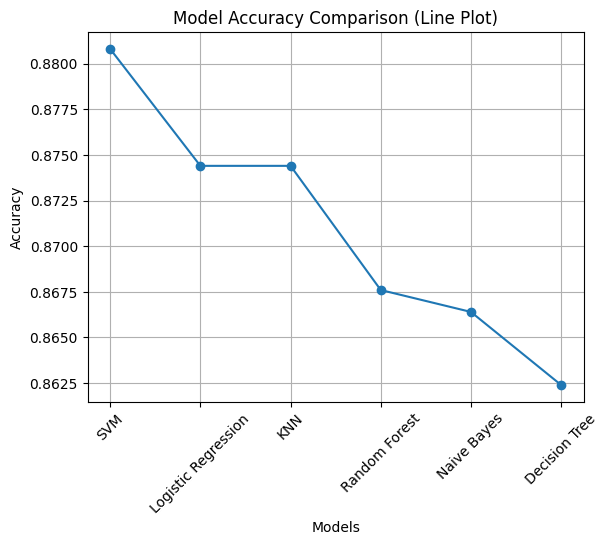

In [70]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(results_df["Model"], results_df["Accuracy"], marker='o')

plt.xticks(rotation=45)
plt.title("Model Accuracy Comparison (Line Plot)")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.grid()
plt.show()